<a href="https://colab.research.google.com/github/Sharvesh8326/24ADI003_24BAD110_ML/blob/main/24BAD110_EXP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name      : Sharvesh S
Roll No   : 24BAD110
SCENARIO 1 – KNN
Accuracy: 0.9298245614035088
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        71
           1       0.91      0.91      0.91        43

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



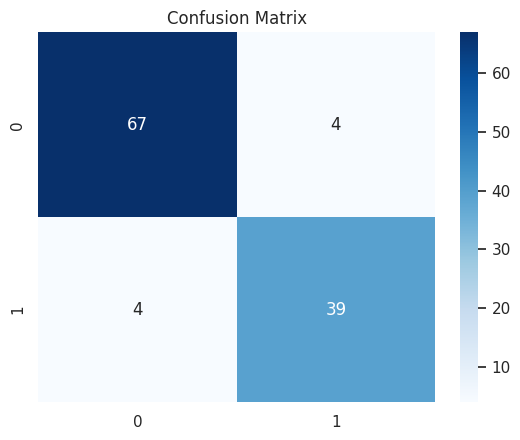

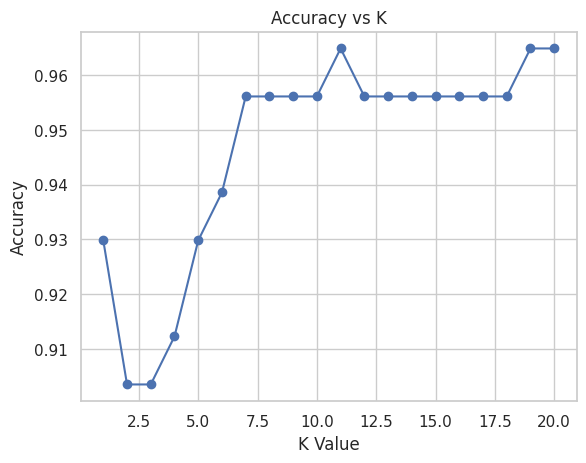

Misclassified Samples: 8


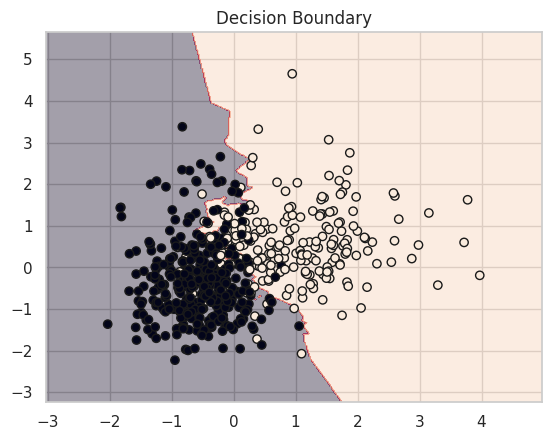

In [2]:
print("Name      : Sharvesh S")
print("Roll No   : 24BAD110")
print("SCENARIO 1 – KNN")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

df = pd.read_csv("breast-cancer.csv")

features = ['radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean']
X = df[features]
y = df['diagnosis']

le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

accuracy_scores = []

for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, pred))

plt.figure()
plt.plot(range(1,21), accuracy_scores, marker='o')
plt.title("Accuracy vs K")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()

misclassified = np.where(y_test != y_pred)
print("Misclassified Samples:", len(misclassified[0]))

X2 = df[['radius_mean','texture_mean']]
X2 = StandardScaler().fit_transform(X2)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.2, random_state=42)

knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train2, y_train2)

h = .02
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X2[:,0], X2[:,1], c=y, edgecolor='k')
plt.title("Decision Boundary")
plt.show()

Name      : Sharvesh S
Roll No   : 24BAD110
SCENARIO 2 – DECISION TREE
Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

       False       0.95      0.42      0.58        43
        True       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



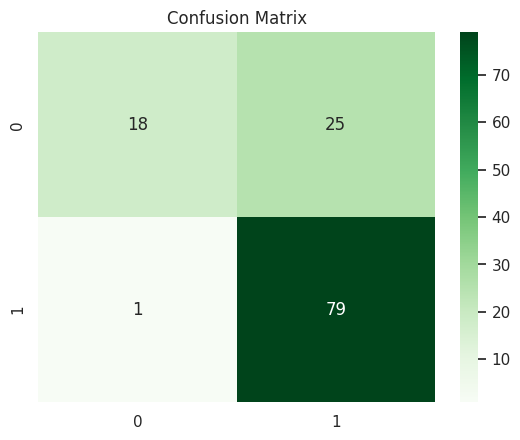

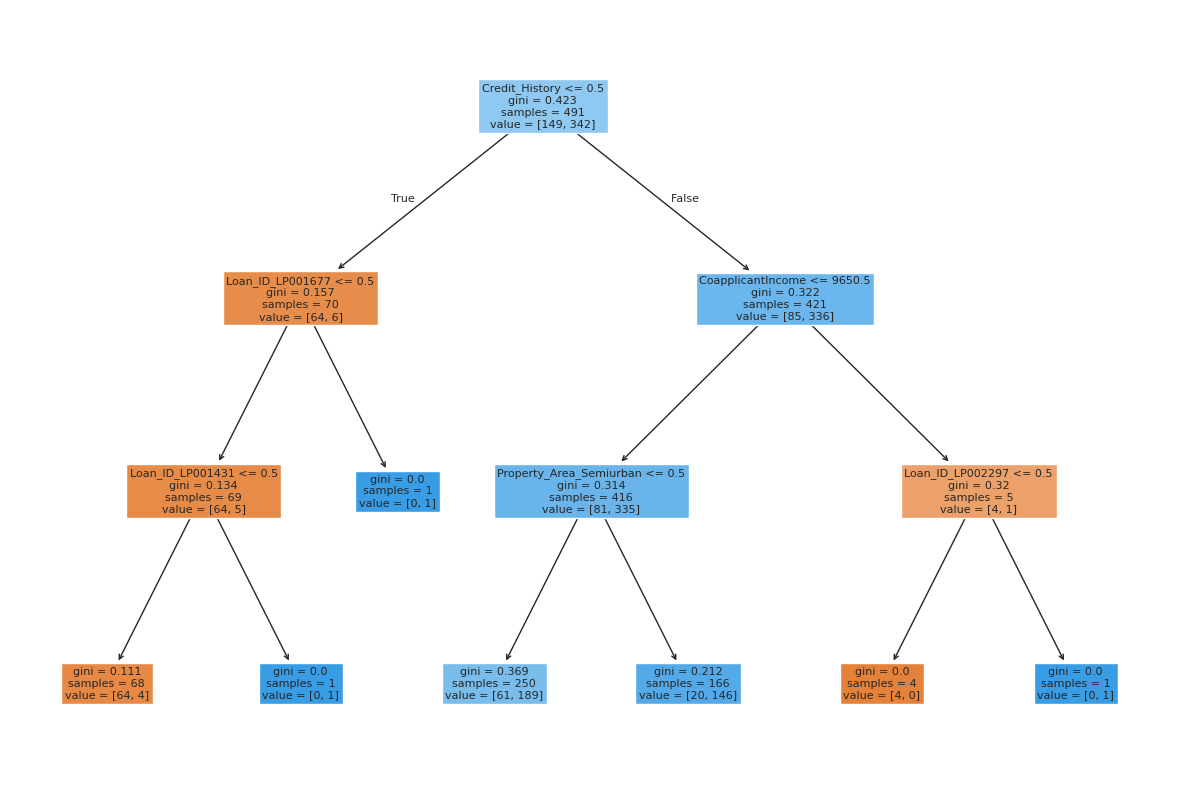

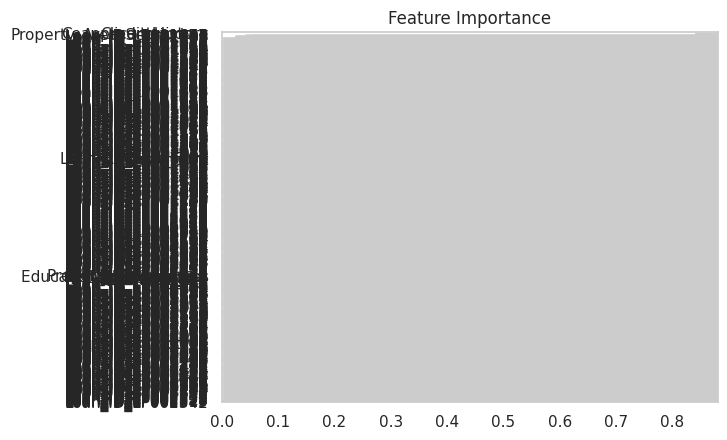

Deep Tree Accuracy: 0.7235772357723578


In [1]:
print("Name      : Sharvesh S")
print("Roll No   : 24BAD110")
print("SCENARIO 2 – DECISION TREE")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

loan_df = pd.read_csv("loan_prediction.csv")

loan_df.fillna(loan_df.mode().iloc[0], inplace=True)
loan_df = pd.get_dummies(loan_df, drop_first=True)

X = loan_df.drop("Loan_Status_Y", axis=1)
y = loan_df["Loan_Status_Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(15,10))
plot_tree(dt, filled=True, feature_names=X.columns)
plt.show()

importance = pd.Series(dt.feature_importances_, index=X.columns)
plt.figure()
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

deep_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
deep_tree.fit(X_train, y_train)

print("Deep Tree Accuracy:", accuracy_score(y_test, deep_tree.predict(X_test)))